# Ensemble Learning for Chronic Kidney Disease
### Student Notebook (Fill in the Missing Code)

This notebook guides you through building machine learning models to predict Chronic Kidney Disease.
Complete the missing code sections marked with `# TODO`.

* Dealing with class imbalance

https://www.analyticsvidhya.com/blog/2020/07/10-techniques-to-deal-with-class-imbalance-in-machine-learning/

## 1. Import Libraries

In [1]:
# TODO: Import required libraries
# pandas, numpy, sklearn modules, matplotlib, seaborn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [6]:
# TODO: Load the dataset 'Chronic_Kidney_Dsease_data.csv'
# Display the first 5 rows
df = pd.read_csv('Chronic_Kidney_Dsease_data.csv')
print(df.head())

   PatientID  Age  Gender  Ethnicity  SocioeconomicStatus  EducationLevel  \
0          1   71       0          0                    0               2   
1          2   34       0          0                    1               3   
2          3   80       1          1                    0               1   
3          4   40       0          2                    0               1   
4          5   43       0          1                    1               2   

         BMI  Smoking  AlcoholConsumption  PhysicalActivity  ...   Itching  \
0  31.069414        1            5.128112          1.676220  ...  7.556302   
1  29.692119        1           18.609552          8.377574  ...  6.836766   
2  37.394822        1           11.882429          9.607401  ...  2.144722   
3  31.329680        0           16.020165          0.408871  ...  7.077188   
4  23.726311        0            7.944146          0.780319  ...  3.553118   

   QualityOfLifeScore  HeavyMetalsExposure  OccupationalExposureChem

## 3. Explore Dataset

In [7]:
# TODO:
# 1. Print dataset shape
# 2. Display column names
# 3. Check for missing values
print("Dataset shape:", df.shape)
print("Column names:", df.columns)
print("Missing values:\n", df.isnull().sum())

Dataset shape: (1659, 54)
Column names: Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus',
       'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension',
       'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury',
       'UrinaryTractInfections', 'SystolicBP', 'DiastolicBP',
       'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR',
       'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium',
       'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium',
       'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
       'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins',
       'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting',
       'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'HeavyMetalsExposure',
       '

## 4. Data Cleaning

In [8]:
# TODO:
# Remove unnecessary columns such as PatientID and DoctorInCharge
df = df.drop(columns=['PatientID', 'DoctorInCharge'])
print("Dataset shape after dropping columns:", df.shape)

Dataset shape after dropping columns: (1659, 52)


## 5. Feature and Target Split

In [9]:
# TODO:
# Separate dataset into X (features) and y (target variable 'Diagnosis')

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']


## 6. Train-Test Split

In [10]:
# TODO:
# Split the data into training and testing sets (e.g., 80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7. Feature Scaling

In [11]:
# TODO:
# Apply StandardScaler to normalize feature values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Train Logistic Regression Model

In [14]:
# TODO:
# Train a Logistic Regression model
# Make predictions on the test set
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_logreg = model.predict(X_test_scaled)

## 9. Train Random Forest Model

In [15]:
# TODO:
# Train a Random Forest model
# Make predictions on the test set
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_rf = model.predict(X_test_scaled)

## 10. Model Evaluation

Accuracy: 0.9367469879518072
Precision: 0.925110552098504
Recall: 0.9367469879518072
F1-score: 0.9202527891722831
Confusion Matrix:
[[  5  19]
 [  2 306]]


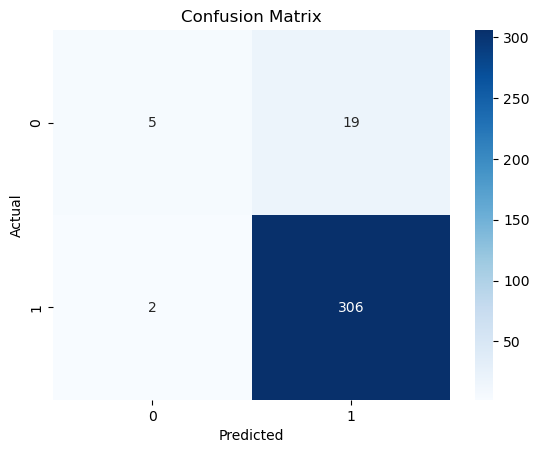

In [17]:
# TODO:
# Calculate Accuracy, Precision, Recall, F1-score
# Display a confusion matrix

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score


accuracy = accuracy_score(y_test, y_pred_logreg)
precision = precision_score(y_test, y_pred_logreg, average='weighted')
recall = recall_score(y_test, y_pred_logreg, average='weighted')
f1 = f1_score(y_test, y_pred_logreg, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

Accuracy: 0.9307228915662651
Precision: 0.9355367087686093
Recall: 0.9307228915662651
F1-score: 0.900102192808794
Confusion Matrix:
[[  1  23]
 [  0 308]]


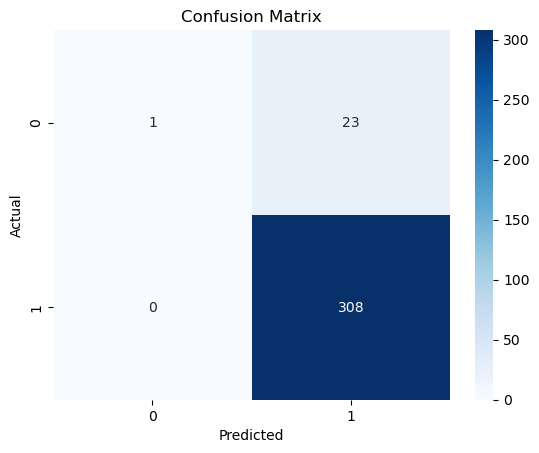

In [18]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

## 11. Ensemble Learning - Stacking

In [19]:
# TODO:
# Create a StackingClassifier using Logistic Regression and Random Forest
# Train the stacking model
# Evaluate performance
from sklearn.ensemble import StackingClassifier
estimators = [
    ('logreg', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=42))
stacking_model.fit(X_train_scaled, y_train)
y_pred_stack = stacking_model.predict(X_test_scaled)

## 12. Handling Class Imbalance

In [23]:
# TODO:
# Apply oversampling (e.g., SMOTE) or undersampling
# Retrain models and compare performance before and after handling class imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


## 13. Final Comparison

In [ ]:
# TODO:
# Create a table comparing performance of:
# Logistic Regression
# Random Forest
# Stacking Model
performance_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Stacking Model'],
    'Accuracy': [accuracy_score(y_test, y_pred_logreg), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_stack)],
    'Precision': [precision_score(y_test, y_pred_logreg, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted'), precision_score(y_test, y_pred_stack, average='weighted')],
    'Recall': [recall_score(y_test, y_pred_logreg, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted'), recall_score(y_test, y_pred_stack, average='weighted')],
    'F1-score': [f1_score(y_test, y_pred_logreg, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted'), f1_score(y_test, y_pred_stack, average='weighted')]
}   
performance_df = pd.DataFrame(performance_data)
print(performance_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.936747   0.925111  0.936747  0.920253
1        Random Forest  0.930723   0.935537  0.930723  0.900102
2       Stacking Model  0.927711   0.899197  0.927711  0.898373


## Reflection Questions
1. Which model performed best and why?
2. How did class imbalance affect model performance?
3. Why might ensemble methods improve prediction accuracy?

Thanks 😀